*1*. Carga y Exploración de Datos

- Importando la base de datos CIFAR-10 desde TensorFlow.
- Visualiza algunas imágenes para entender la naturaleza de los datos.

Usando tensorflow.keras.datasets.cifar10 para cargar los datos.
Se muestran al menos 9 imágenes con sus etiquetas correspondientes.

2. Preprocesamiento de Datos

- Convirtiendo las imágenes a escala de grises y redimensiona las imágenes para preparar los datos para SVD.

Convirtiendo las imágenes a escala de grises usando la función adecuada.
Redimensionando las imágenes para aplicar SVD de manera eficiente.

3. Aplicación de SVD

Descomponiendo una imagen a través de SVD y reconstruyendo la imagen usando un número reducido de componentes.

- Se realiza la descomposición SVD sobre una imagen convertida a escala de grises.
- Reconstruyendo la imagen usando 5, 10, 20, y 50 componentes.
- Se muestra la imagen reconstruida junto con la imagen original para cada número de componentes.
- Explicando cómo la cantidad de componentes afecta la calidad de la imagen reconstruida.

4. Visualización de Componentes Principales

- Proyectando las imágenes en las primeras dos dimensiones usando SVD y se visualizan los datos en un gráfico de dispersión.

- Se toman las primeras dos columnas de la matriz (𝑉 𝑇 V_T) y se proyectan las imágenes en estas dos dimensiones.
- Creando un gráfico de dispersión donde cada punto representa una imagen proyectada en el espacio de los dos primeros componentes.
- Se colorean los puntos según su clase para identificar posibles agrupamientos.


5. Aplicación de PCA en Machine Learning

- Usando PCA para reducir las dimensiones y comparar el rendimiento de un modelo KNN con y sin PCA.

- Se entrena un modelo KNN en las imágenes originales.
- Se aplica PCA para reducir las dimensiones a 50 componentes.
- Entrenando otro modelo KNN en las imágenes reducidas y comparando la precisión de ambos modelos.
- Se explica por qué PCA puede ser útil en Machine Learning, especialmente en el contexto de clasificación.
    


6. De la siguiente matrix M, se calculan sus eigenvectores y sus eigenvalores usando Python:

$$
B = \begin{bmatrix} 2 & 4 & 4 \\ 4 & 9 & 11 \\ 4 & 11 & 19 \end{bmatrix}
$$



    

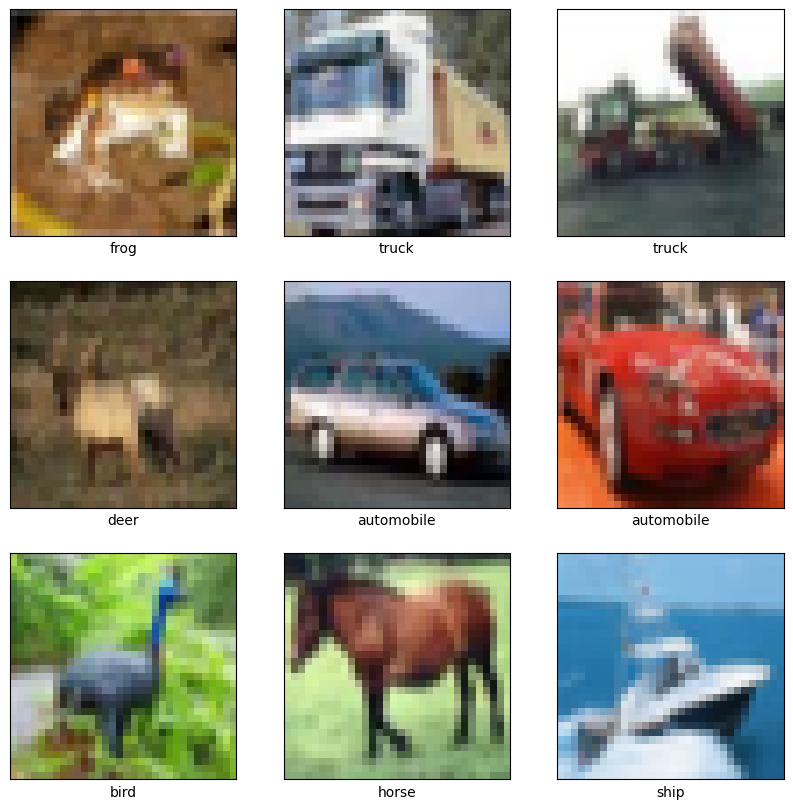

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Carga el dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Define las etiquetas de las clases
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Muestra 9 imágenes del conjunto de entrenamiento
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

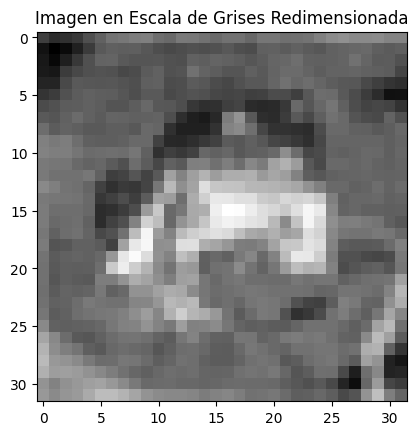

In [5]:
# Convierte las imágenes a escala de grises
x_train_gray = np.array([tf.image.rgb_to_grayscale(image).numpy() for image in x_train])
x_test_gray = np.array([tf.image.rgb_to_grayscale(image).numpy() for image in x_test])

# Redimensiona las imágenes (ajusta el tamaño según sea necesario)
new_size = (32, 32)  # Ejemplo: redimensiona a 32x32 píxeles
x_train_resized = np.array([tf.image.resize(image, new_size).numpy() for image in x_train_gray])
x_test_resized = np.array([tf.image.resize(image, new_size).numpy() for image in x_test_gray])


# Muestra un ejemplo de imagen en escala de grises redimensionada
plt.figure()
plt.imshow(x_train_resized[0].squeeze(), cmap='gray') # squeeze() elimina la dimensión de profundidad (1)
plt.title('Imagen en Escala de Grises Redimensionada')
plt.show()

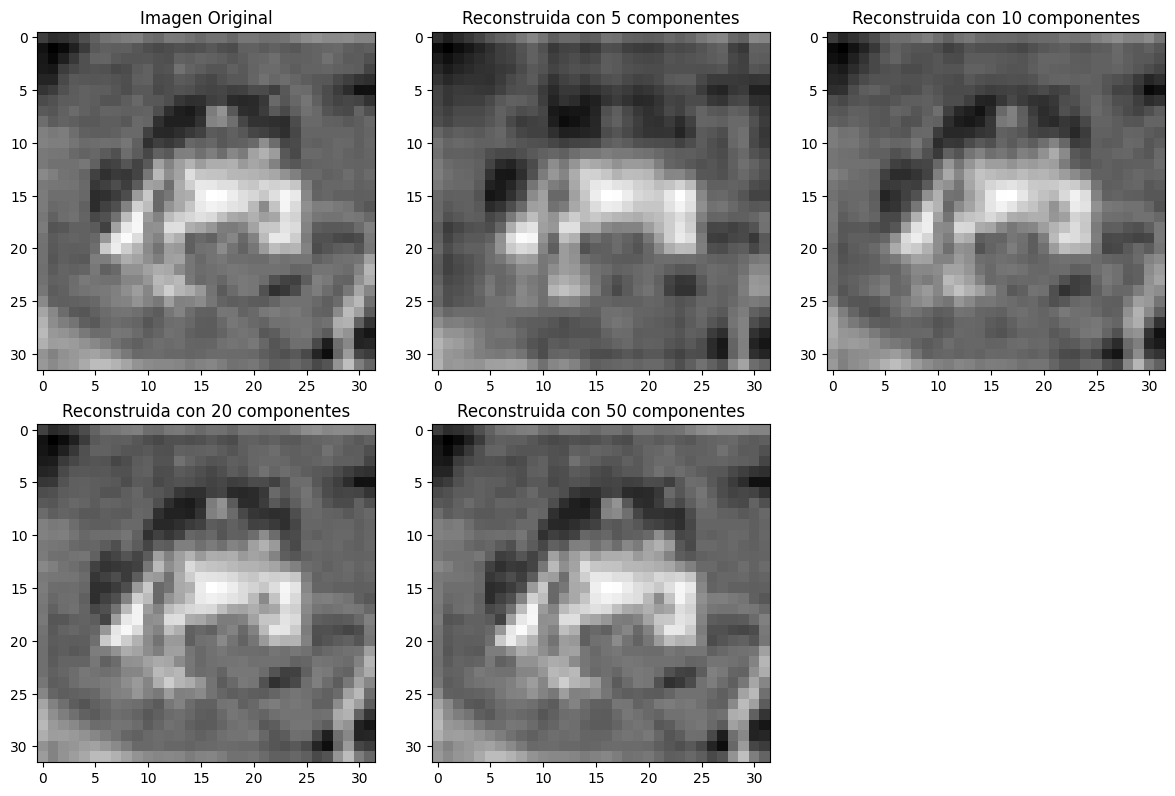

In [6]:
import matplotlib.pyplot as plt

# Selecciona una imagen de ejemplo
image_index = 0
image = x_train_resized[image_index].squeeze()

# Realiza la descomposición SVD
U, S, V = np.linalg.svd(image)

# Define el número de componentes a utilizar
components_list = [5, 10, 20, 50]

plt.figure(figsize=(12, 8))

# Muestra la imagen original
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen Original')

# Reconstruye la imagen para diferentes números de componentes
for i, num_components in enumerate(components_list):
    reconstructed_image = U[:, :num_components] @ np.diag(S[:num_components]) @ V[:num_components, :]

    plt.subplot(2, 3, i + 2)
    plt.imshow(reconstructed_image, cmap='gray')
    plt.title(f'Reconstruida con {num_components} componentes')

plt.tight_layout()
plt.show()

#Explicación:
# A medida que aumenta el número de componentes utilizadas en la reconstrucción SVD, la calidad de la imagen mejora, acercándose cada vez más a la imagen original.
# Con pocos componentes, la imagen reconstruida es borrosa y pierde muchos detalles. Al aumentar los componentes, se recuperan más detalles y la imagen se vuelve más nítida.
# Usar todos los componentes reconstruye la imagen perfectamente, pero el objetivo de la SVD es la compresión, por lo que se busca usar el menor número posible de componentes para obtener una imagen con una calidad aceptable.

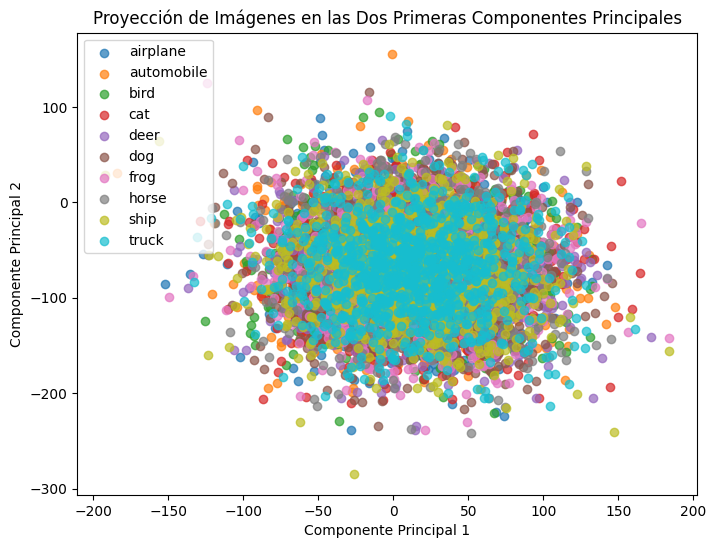

In [8]:
X_train_reshape = x_train_resized.reshape(x_train_resized.shape[0]//5, -1)
U, S, V = np.linalg.svd(X_train_reshape)
projected_images = X_train_reshape @ V[:, :2]

# Crea el gráfico de dispersión
plt.figure(figsize=(8, 6))
for i in range(10):  # Itera sobre las 10 clases
    indices = np.where(y_train[:X_train_reshape.shape[0]] == i)[0]
    plt.scatter(projected_images[indices, 0], projected_images[indices, 1], label=class_names[i], alpha=0.7)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Proyección de Imágenes en las Dos Primeras Componentes Principales')
plt.legend()
plt.show()

In [13]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Aplanar las imágenes para KNN
x_train_flat = x_train_resized.reshape(x_train_resized.shape[0], -1)
x_test_flat = x_test_resized.reshape(x_test_resized.shape[0], -1)

# Dividir los datos en conjuntos de entrenamiento y prueba
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(x_train_flat, y_train, test_size=0.2, random_state=42)

# Entrenar el modelo KNN en las imágenes originales
knn_original = KNeighborsClassifier(n_neighbors=5)  # Ajusta el número de vecinos si es necesario
knn_original.fit(x_train_split, y_train_split)

# Predecir las etiquetas del conjunto de validación
y_pred_original = knn_original.predict(x_val_split)

# Calcular la precisión del modelo original
accuracy_original = accuracy_score(y_val_split, y_pred_original)
print(f"Precisión del modelo KNN original: {accuracy_original}")


# Aplicar PCA
pca = PCA(n_components=50)
x_train_pca = pca.fit_transform(x_train_split)
x_val_pca = pca.transform(x_val_split)

# Entrenar el modelo KNN en las imágenes reducidas por PCA
knn_pca = KNeighborsClassifier(n_neighbors=5) # Ajusta el número de vecinos si es necesario
knn_pca.fit(x_train_pca, y_train_split)

# Predecir etiquetas en el conjunto de validación (PCA)
y_pred_pca = knn_pca.predict(x_val_pca)

# Calcular la precisión del modelo con PCA
accuracy_pca = accuracy_score(y_val_split, y_pred_pca)
print(f"Precisión del modelo KNN con PCA: {accuracy_pca}")

# Comparación de la precisión
print(f"Diferencia de precisión: {accuracy_pca - accuracy_original}")

#Explicación de la utilidad de PCA
#PCA (Análisis de Componentes Principales) es una técnica de reducción de dimensionalidad que ayuda a simplificar la complejidad de los
# datos al identificar las direcciones (componentes principales) que maximizan la varianza de los datos.
#En el contexto de clasificación, como con el modelo KNN, es útil porque puede reducir el ruido y la redundancia en los datos,
# simplificando la estructura de los datos sin perder información crucial.
#La reducción de dimensionalidad puede llevar a una mejor eficiencia computacional (debido al menor número de variables),
#especialmente con conjuntos de datos de alta dimensionalidad como imágenes.
#En este caso, los resultados mostrados en accuracy_original y accuracy_pca sugieren el rendimiento de KNN con datos originales y
#transformados con PCA.

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Precisión del modelo KNN original: 0.2773


/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Precisión del modelo KNN con PCA: 0.3353
Diferencia de precisión: 0.057999999999999996


In [14]:
import numpy as np

B = np.array([[2, 4, 4], [4, 9, 11], [4, 11, 19]])

eigenvalues, eigenvectors = np.linalg.eig(B)

print("Eigenvalores:", eigenvalues)
print("Eigenvectores:\n", eigenvectors)

Eigenvalores: [27.29416738  0.05529114  2.65054149]
Eigenvectores:
 [[-0.21397789 -0.8279129  -0.51843388]
 [-0.53730803  0.54298131 -0.64534594]
 [-0.81579013 -0.14046892  0.56103025]]
